# 🎬 Movie Recommender System
## Hybrid Approch: SVD (Collaborative Filtering) + (Content-Based Filtering)


*What problem are we solving?*

In today's digital world, platforms like Netflix, Amazon Prime, and YouTube host millions of movies and shows. Users cannot manually browse through everything they need an intelligent system that automatically finds exactly what they will enjoy. This is the movie recommendation problem.

In [1]:
# Download and extract MovieLens dataset
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -o ml-latest-small.zip

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
rating_data = pd.read_csv("ml-latest-small/ratings.csv")
movie_data = pd.read_csv("ml-latest-small/movies.csv")

# Merge into single dataframe
full_df = pd.merge(rating_data, movie_data, on="movieId")

print("Dataset loaded successfully!")
display(full_df.head())



--2026-02-22 22:11:10--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip.6’

ml-latest-small.zip 100%[===================>] 955.28K  6.01MB/s    in 0.2s    

2026-02-22 22:11:11 (6.01 MB/s) - ‘ml-latest-small.zip.6’ saved [978202/978202]

Archive:  ml-latest-small.zip
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  
Dataset loaded successfully!


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [2]:
# Dataset summary
n_users = full_df["userId"].nunique()
n_movies = full_df["movieId"].nunique()
n_ratings = len(full_df)

print(f"=== Dataset Overview ===")
print(f"Unique Users  : {n_users}")
print(f"Unique Movies : {n_movies}")
print(f"Total Ratings : {n_ratings}")

=== Dataset Overview ===
Unique Users  : 610
Unique Movies : 9724
Total Ratings : 100836


## Exploratory Data Analysis
Checking sparsity and rating distribution

In [3]:
# Sparsity
total_possible = n_users * n_movies
density = n_ratings / total_possible
sparsity_pct = (1 - density) * 100

print("=== Sparsity Analysis ===")
print(f"Matrix Density  : {density*100:.4f}%")
print(f"Matrix Sparsity : {sparsity_pct:.4f}%")

=== Sparsity Analysis ===
Matrix Density  : 1.7000%
Matrix Sparsity : 98.3000%


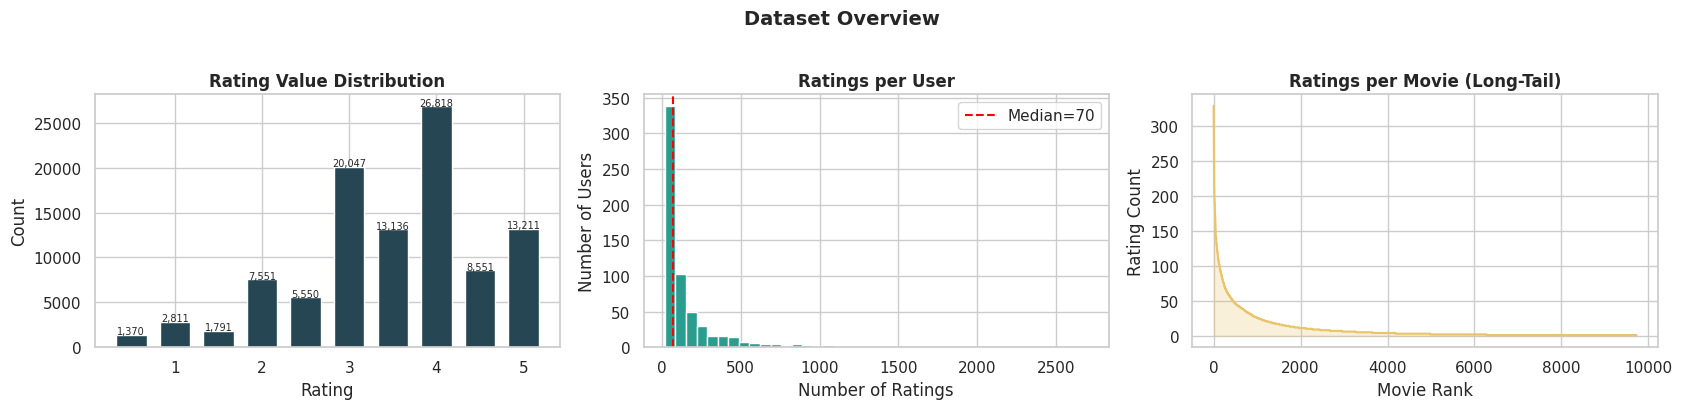

In [4]:
# Custom color palette ──
PALETTE = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
sns.set_theme(style='whitegrid', palette=PALETTE)

# Rating Distribution
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Rating value counts
rating_counts = full_df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=PALETTE[0], width=0.35, edgecolor='white')
axes[0].set_title('Rating Value Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+80, f'{val:,}',
                 ha='center', fontsize=7)

# Ratings per user (histogram)
user_rating_counts = full_df.groupby('userId').size()
axes[1].hist(user_rating_counts, bins=40, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Ratings'); axes[1].set_ylabel('Number of Users')
axes[1].axvline(user_rating_counts.median(), color='red', linestyle='--', label=f'Median={user_rating_counts.median():.0f}')
axes[1].legend()

# Ratings per movie (long-tail)
movie_rating_counts = full_df.groupby('movieId').size().sort_values(ascending=False)
axes[2].plot(range(len(movie_rating_counts)), movie_rating_counts.values, color=PALETTE[2], linewidth=1.5)
axes[2].fill_between(range(len(movie_rating_counts)), movie_rating_counts.values, alpha=0.25, color=PALETTE[2])
axes[2].set_title('Ratings per Movie (Long-Tail)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Movie Rank'); axes[2].set_ylabel('Rating Count')

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


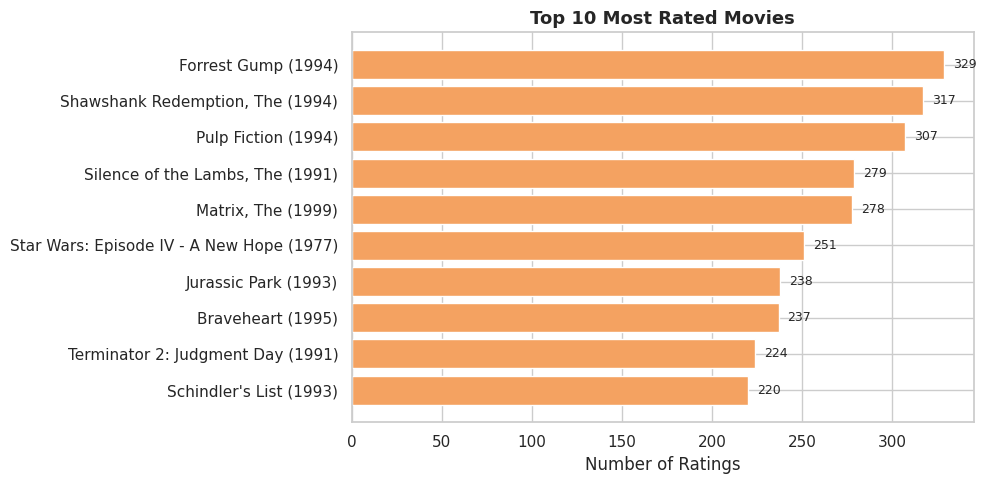

In [5]:
# Top 10 Most Rated Movies
top_movies = (full_df.groupby('title')['rating']
              .agg(['count','mean'])
              .rename(columns={'count':'num_ratings','mean':'avg_rating'})
              .sort_values('num_ratings', ascending=False)
              .head(10)
              .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_movies['title'][::-1], top_movies['num_ratings'][::-1],
               color=PALETTE[3], edgecolor='white')
ax.set_title('Top 10 Most Rated Movies', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Ratings')
for bar in bars:
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## Data Preprocessing
Filtering noisy data, encoding IDs, and splitting train/test sets

In [6]:
import re
from sklearn.model_selection import train_test_split

original_size = len(full_df)

# Keep users with at least 20 ratings
user_activity = full_df["userId"].value_counts()
engaged_users = user_activity[user_activity >= 20].index
full_df = full_df[full_df["userId"].isin(engaged_users)]

# Keep movies with at least 10 ratings
movie_activity = full_df["movieId"].value_counts()
rated_movies = movie_activity[movie_activity >= 10].index
full_df = full_df[full_df["movieId"].isin(rated_movies)]

print(f"Removed {original_size - len(full_df)} low-signal interactions.")
print(f"Remaining interactions: {len(full_df)}")

print("---  Feature Extraction ---")
full_df["release_year"] = full_df["title"].str.extract(r"\((\d{4})\)")
full_df["release_year"] = full_df["release_year"].fillna("0")
full_df["genre_text"] = full_df["genres"].str.replace("|", " ", regex=False).str.lower()
print("Extracted release_year and genre_text columns.")

print("---  ID Encoding ---")
unique_users = full_df["userId"].unique()
unique_movies = full_df["movieId"].unique()

user_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
movie_to_idx = {mid: idx for idx, mid in enumerate(unique_movies)}

full_df["user_idx"] = full_df["userId"].map(user_to_idx)
full_df["movie_idx"] = full_df["movieId"].map(movie_to_idx)
print("User and movie IDs encoded.")

print("--- Train/Test Split  ---")
train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42)
print(f"Training samples : {len(train_df)}")
print(f"Testing samples  : {len(test_df)}")

Removed 19720 low-signal interactions.
Remaining interactions: 81116
---  Feature Extraction ---
Extracted release_year and genre_text columns.
---  ID Encoding ---
User and movie IDs encoded.
--- Train/Test Split  ---
Training samples : 64892
Testing samples  : 16224


## User Rating Normalization (Mean-Centering)
Removing individual user bias by centering ratings around each users mean

In [7]:
import pandas as pd

print("Computing per-user average ratings from training set...")

per_user_avg = train_df.groupby("user_idx")["rating"].mean().reset_index()
per_user_avg.rename(columns={"rating": "avg_rating"}, inplace=True)

train_df = pd.merge(train_df, per_user_avg, on="user_idx", how="left")
test_df = pd.merge(test_df, per_user_avg, on="user_idx", how="left")

global_avg = train_df["rating"].mean()
test_df["avg_rating"] = test_df["avg_rating"].fillna(global_avg)

train_df["centered_rating"] = train_df["rating"] - train_df["avg_rating"]
test_df["centered_rating"] = test_df["rating"] - test_df["avg_rating"]

print("Mean-centering complete. User biases neutralized.")
display(train_df[["user_idx", "movie_idx", "rating", "avg_rating", "centered_rating"]].head())

Computing per-user average ratings from training set...
Mean-centering complete. User biases neutralized.


,user_idx,movie_idx,rating,avg_rating,centered_rating
0,299,34,4.0,4.384615,-0.384615
1,583,402,5.0,4.181818,0.818182
2,216,1978,3.0,2.814404,0.185596
3,225,341,4.0,3.575071,0.424929
4,342,1943,5.0,4.090909,0.909091


## Model Development
Collaborative Filtering using SVD

In [17]:
# Install compatible versions
!pip uninstall -y numpy scikit-surprise
!pip install "numpy<2.0.0" scikit-surprise

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 11.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 57.1 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554982 sha256=49064b0adb68c876eb94d71191a3817a38ead27d14ae57f48fe1060f48564632
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires n

In [8]:
# Reload data after kernel changes
import pandas as pd
from sklearn.model_selection import train_test_split

rating_data = pd.read_csv("ml-latest-small/ratings.csv")
movie_data = pd.read_csv("ml-latest-small/movies.csv")
full_df = pd.merge(rating_data, movie_data, on="movieId")

user_activity = full_df["userId"].value_counts()
full_df = full_df[full_df["userId"].isin(user_activity[user_activity >= 20].index)]

movie_activity = full_df["movieId"].value_counts()
full_df = full_df[full_df["movieId"].isin(movie_activity[movie_activity >= 10].index)]

train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42)
print(f"Data reloaded: {len(train_df)} train / {len(test_df)} test samples.")

Data reloaded: 64892 train / 16224 test samples.


In [9]:
import pandas as pd
from surprise import Dataset, Reader, SVD
from surprise import accuracy

reader = Reader(rating_scale=(0.5, 5.0))
train_surprise = Dataset.load_from_df(train_df[["userId", "movieId", "rating"]], reader)

trainset = train_surprise.build_full_trainset()
testset = [tuple(x) for x in test_df[["userId", "movieId", "rating"]].values]

print("Training SVD model with 100 latent factors...")
cf_model = SVD(n_factors=100,random_state=42)
cf_model.fit(trainset)
print("SVD training complete!")

print("Evaluating on test set...")
cf_predictions = cf_model.test(testset)
rmse_cf = accuracy.rmse(cf_predictions, verbose=False)
mae_cf = accuracy.mae(cf_predictions, verbose=False)

print(f"RMSE : {rmse_cf:.4f}")
print(f"MAE  : {mae_cf:.4f}")

Training SVD model with 100 latent factors...
SVD training complete!
Evaluating on test set...
RMSE : 0.8553
MAE  : 0.6546


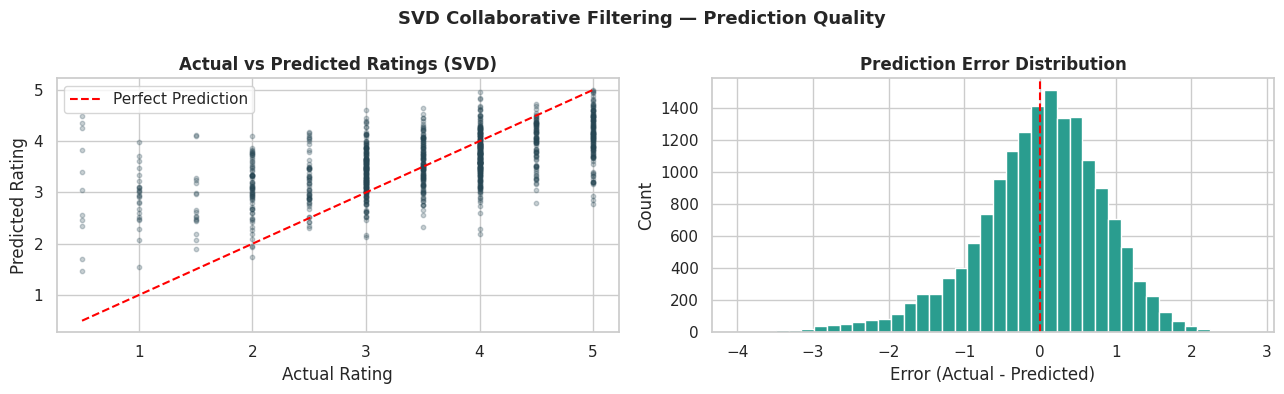

In [10]:
# Visualise predicted vs actual ratings
pred_df = pd.DataFrame({
    'actual': [p.r_ui for p in cf_predictions],
    'predicted': [p.est for p in cf_predictions]
})
# Sample for visibility
sample = pred_df.sample(n=min(1000, len(pred_df)), random_state=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(sample['actual'], sample['predicted'], alpha=0.25, s=10, color=PALETTE[0])
axes[0].plot([0.5, 5.0], [0.5, 5.0], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Ratings (SVD)', fontweight='bold')
axes[0].set_xlabel('Actual Rating'); axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

errors = pred_df['actual'] - pred_df['predicted']
axes[1].hist(errors, bins=40, color=PALETTE[1], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Prediction Error Distribution', fontweight='bold')
axes[1].set_xlabel('Error (Actual - Predicted)'); axes[1].set_ylabel('Count')

plt.suptitle('SVD Collaborative Filtering — Prediction Quality', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Content-Based Filtering using TF-IDF on Genre Features

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movie_features = movie_data.copy()
movie_features["genre_clean"] = movie_features["genres"].str.replace("|", " ", regex=False).str.lower()

vectorizer = TfidfVectorizer(stop_words="english")
genre_matrix = vectorizer.fit_transform(movie_features["genre_clean"])
print(f"TF-IDF matrix shape: {genre_matrix.shape}")

sim_matrix = cosine_similarity(genre_matrix, genre_matrix)
print("Similarity matrix ready.")

title_index = pd.Series(movie_features.index, index=movie_features["title"]).drop_duplicates()

def recommend_by_content(movie_title, top_k=10):
    if movie_title not in title_index:
        return f"Movie not found: {movie_title}"
    idx = title_index[movie_title]
    sim_scores = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
    top_indices = [s[0] for s in sim_scores[1:top_k+1]]
    return movie_features["title"].iloc[top_indices].tolist()

for rank, title in enumerate(recommend_by_content("Screamers (1995)"), 1):
    print(f"  {rank}. {title}")

TF-IDF matrix shape: (9742, 23)
Similarity matrix ready.
  1. Screamers (1995)
  2. Johnny Mnemonic (1995)
  3. Virtuosity (1995)
  4. Timecop (1994)
  5. Blade Runner (1982)
  6. Solo (1996)
  7. Arrival, The (1996)
  8. Terminator, The (1984)
  9. Godzilla (1998)
  10. Matrix, The (1999)


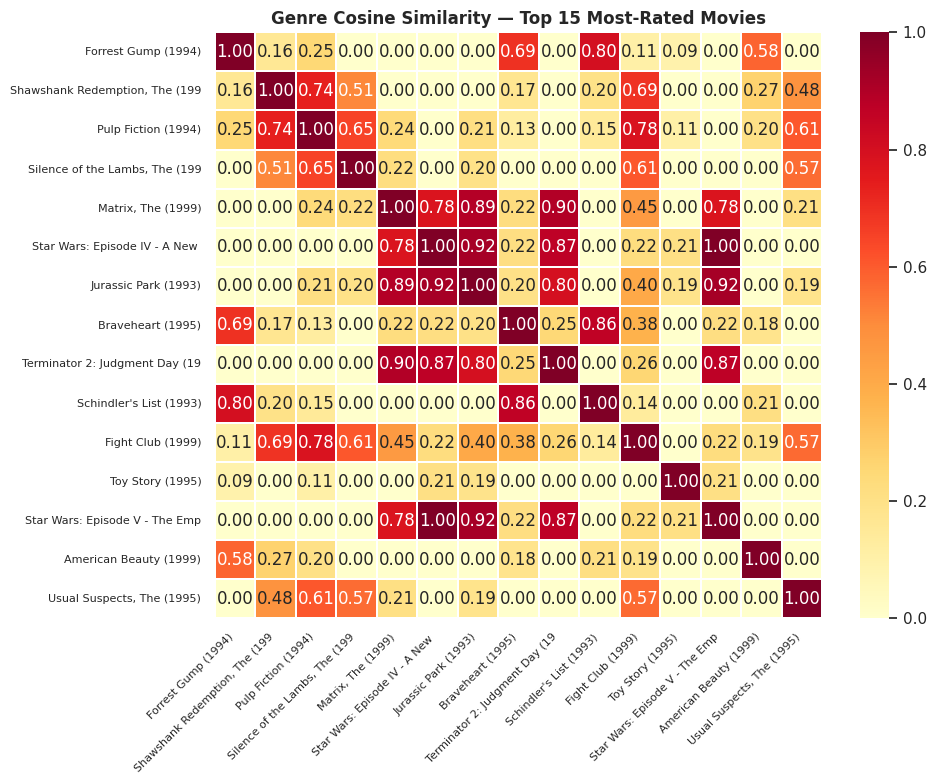

In [12]:
# ── Visualise the Genre TF-IDF matrix as a heatmap (top 15 movies) ──
top15_titles = full_df.groupby('title')['rating'].count().nlargest(15).index.tolist()
top15_idx = [title_index[t] for t in top15_titles if t in title_index]
top15_labels = [movie_features['title'].iloc[i][:30] for i in top15_idx]

sim_sub = sim_matrix[np.ix_(top15_idx, top15_idx)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_sub, xticklabels=top15_labels, yticklabels=top15_labels,
            cmap='YlOrRd', annot=True, fmt='.2f', ax=ax, linewidths=0.3)
ax.set_title('Genre Cosine Similarity — Top 15 Most-Rated Movies', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

### Hybrid Recommender System

In [13]:
def hybrid_recommend(user_id, seed_movie, top_k=10, candidate_pool=60):
    if seed_movie not in title_index:
        return f"Seed movie not found: {seed_movie}"

    print(f"Hybrid recommendations for User {user_id} | Seed: {seed_movie}")

    seed_idx = title_index[seed_movie]
    sim_scores = sorted(enumerate(sim_matrix[seed_idx]), key=lambda x: x[1], reverse=True)
    candidate_indices = [s[0] for s in sim_scores[1:candidate_pool+1]]

    candidate_movies = movie_features.iloc[candidate_indices][["movieId", "title"]].copy()
    candidate_movies["predicted_rating"] = candidate_movies["movieId"].apply(
        lambda mid: cf_model.predict(user_id, mid).est
    )

    final_recs = candidate_movies.sort_values("predicted_rating", ascending=False)
    return final_recs.head(top_k).reset_index(drop=True)



In [14]:
# Test 1
result1 = hybrid_recommend(user_id=2, seed_movie="Island, The (2005)")
display(result1)

Hybrid recommendations for User 2 | Seed: Island, The (2005)


,movieId,title,predicted_rating
0,2571,"Matrix, The (1999)",4.058537
1,1240,"Terminator, The (1984)",4.013886
2,541,Blade Runner (1982),4.011176
3,589,Terminator 2: Judgment Day (1991),3.845487
4,5903,Equilibrium (2002),3.801243
5,3527,Predator (1987),3.741038
6,122920,Captain America: Civil War (2016),3.704092
7,79057,Predators (2010),3.693693
8,2600,eXistenZ (1999),3.676178
9,76,Screamers (1995),3.619256


In [15]:
# Test 2
result2 = hybrid_recommend(user_id=25, seed_movie="Toy Story (1995)")
display(result2)

--- user_id=205 ---
Hybrid recommendations for User 25 | Seed: Toy Story (1995)


,movieId,title,predicted_rating
0,4886,"Monsters, Inc. (2001)",4.732336
1,6377,Finding Nemo (2003),4.697131
2,2138,Watership Down (1978),4.612487
3,4306,Shrek (2001),4.610995
4,108932,The Lego Movie (2014),4.543153
5,26662,Kiki's Delivery Service (Majo no takkyûbin) (1...,4.491930
6,38038,Wallace & Gromit in The Curse of the Were-Rabb...,4.477586
7,3114,Toy Story 2 (1999),4.440050
8,134853,Inside Out (2015),4.415030
9,65261,Ponyo (Gake no ue no Ponyo) (2008),4.376986


In [16]:


# Test 3
result3 = hybrid_recommend(user_id=842, seed_movie="Titanic (1997)")
display(result3)

User 400 | Pulp Fiction (1994) ---
Hybrid recommendations for User 842 | Seed: Titanic (1997)


,movieId,title,predicted_rating
0,912,Casablanca (1942),4.234096
1,1357,Shine (1996),3.943615
2,1059,William Shakespeare's Romeo + Juliet (1996),3.877113
3,222,Circle of Friends (1995),3.833312
4,28,Persuasion (1995),3.819694
5,215,Before Sunrise (1995),3.815251
6,902,Breakfast at Tiffany's (1961),3.807306
7,1296,"Room with a View, A (1986)",3.794258
8,249,Immortal Beloved (1994),3.767242
9,1393,Jerry Maguire (1996),3.754939


## Evaluation
### Top-N Metrics: Precision@10, Recall@10, Hit Rate@10, NDCG@10

In [17]:
import numpy as np
from collections import defaultdict

def build_top_n(predictions, n=10):
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((iid, est, true_r))
    for uid in user_preds:
        user_preds[uid].sort(key=lambda x: x[1], reverse=True)
        user_preds[uid] = user_preds[uid][:n]
    return user_preds

def compute_ranking_metrics(predictions, k=10, threshold=3.5):
    top_n = build_top_n(predictions, n=k)
    precision_list, recall_list, hit_list, ndcg_list = [], [], [], []

    for uid, top_items in top_n.items():
        all_user_preds = [p for p in predictions if p.uid == uid]
        total_relevant = sum(p.r_ui >= threshold for p in all_user_preds)
        relevant_in_top = sum(true_r >= threshold for _, _, true_r in top_items)

        precision_list.append(relevant_in_top / k)
        recall_list.append(relevant_in_top / total_relevant if total_relevant > 0 else 0)
        hit_list.append(1 if relevant_in_top > 0 else 0)

        dcg = sum(1.0 / np.log2(i + 2) for i, (_, _, true_r) in enumerate(top_items) if true_r >= threshold)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(total_relevant, k)))
        ndcg_list.append(dcg / idcg if idcg > 0 else 0)

    return np.mean(precision_list), np.mean(recall_list), np.mean(hit_list), np.mean(ndcg_list)

print("Computing Top-N metrics (k=10, threshold=3.5)...")
p10, r10, hr10, ndcg10 = compute_ranking_metrics(cf_predictions, k=10, threshold=3.5)

print(f"Precision@10 : {p10:.4f}")
print(f"Recall@10    : {r10:.4f}")
print(f"Hit Rate@10  : {hr10:.4f}")
print(f"NDCG@10      : {ndcg10:.4f}")

Computing Top-N metrics (k=10, threshold=3.5)...
Precision@10 : 0.6206
Recall@10    : 0.6857
Hit Rate@10  : 0.9852
NDCG@10      : 0.8504


## Performance Comparison: Hybrid Model vs. Baseline

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import namedtuple
import pandas as pd
import numpy as np

print("Computing baseline metrics (Global Mean predictor)...")
global_mean_rating = train_df["rating"].mean()
actual_ratings = test_df["rating"]
baseline_preds = [global_mean_rating] * len(actual_ratings)

rmse_base = np.sqrt(mean_squared_error(actual_ratings, baseline_preds))
mae_base = mean_absolute_error(actual_ratings, baseline_preds)

FakePred = namedtuple("FakePred", ["uid", "iid", "r_ui", "est", "details"])
base_fake_preds = [
    FakePred(uid=row["userId"], iid=row["movieId"], r_ui=row["rating"], est=global_mean_rating, details=None)
    for _, row in test_df.iterrows()
]

bp10, br10, bhr10, bndcg10 = compute_ranking_metrics(base_fake_preds, k=10, threshold=3.5)

summary = pd.DataFrame({
    "Model": ["Global Mean Baseline", "SVD Hybrid Recommender"],
    "RMSE": [round(rmse_base, 4), round(rmse_cf, 4)],
    "MAE": [round(mae_base, 4), round(mae_cf, 4)],
    "Precision@10": [round(bp10, 4), round(p10, 4)],
    "Recall@10": [round(br10, 4), round(r10, 4)],
    "Hit Rate@10": [round(bhr10, 4), round(hr10, 4)],
    "NDCG@10": [round(bndcg10, 4), round(ndcg10, 4)]
})


Computing baseline metrics (Global Mean predictor)...


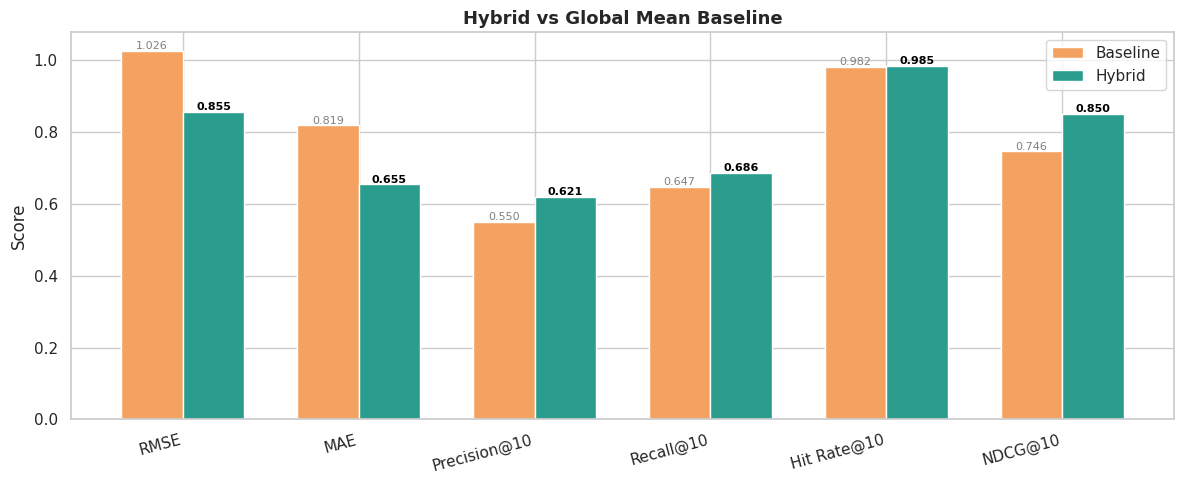

In [19]:
# Final Results Comparison
metrics = ['RMSE', 'MAE', 'Precision@10', 'Recall@10', 'Hit Rate@10', 'NDCG@10']
baseline_vals = summary[summary['Model']=='Global Mean Baseline'][metrics].values[0]
Hybrid_model    = summary[summary['Model']=='SVD Hybrid Recommender'][metrics].values[0]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, baseline_vals, w, label='Baseline', color=PALETTE[3], edgecolor='white')
bars2 = ax.bar(x + w/2, Hybrid_model,    w, label='Hybrid', color=PALETTE[1], edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.set_title('Hybrid vs Global Mean Baseline', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8, color='gray')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8, color='black', fontweight='bold')

plt.tight_layout(); plt.show()


**Conclusion:**

The Hybrid model performs better than the baseline model. It has lower RMSE and MAE, which means it predicts user ratings more accurately.The Hybrid model has higher Precision, NDCG, and Recall, showing that it recommends more relevant movies at the top. Overall, the Hybrid approach provides better and more accurate recommendations.